In [1]:
import time
from typing import Dict, List, Optional, Set


class CSP:
    def __init__(self, variables, domains, neighbors):
        self.variables = variables
        self.domains = domains
        self.neighbors = neighbors

        self.nodes_expanded = 0
        self.backtracks = 0
        self._deadline = None
        self.timed_out = False

    def is_consistent(self, var, value, assignment):
        for neighbor in self.neighbors[var]:
            if neighbor in assignment and assignment[neighbor] == value:
                return False
        return True

    def mrv(self, assignment):
        unassigned = [v for v in self.variables if v not in assignment]

        def count_valid_values(var):
            count = 0
            for val in self.domains[var]:
                if self.is_consistent(var, val, assignment):
                    count += 1
            return count

        return min(unassigned, key=count_valid_values)

    def backtrack(self, assignment, use_mrv):
        if self._deadline is not None and time.perf_counter() > self._deadline:
            self.timed_out = True
            return None

        if len(assignment) == len(self.variables):
            return dict(assignment)

        if use_mrv:
            var = self.mrv(assignment)
        else:
            var = [v for v in self.variables if v not in assignment][0]

        self.nodes_expanded += 1

        for value in self.domains[var]:
            if self.is_consistent(var, value, assignment):
                assignment[var] = value

                result = self.backtrack(assignment, use_mrv)
                if result is not None:
                    return result

                del assignment[var]
                self.backtracks += 1

        return None

    def backtracking_search(self, use_mrv=False, time_limit=None):
        self.nodes_expanded = 0
        self.backtracks = 0
        self.timed_out = False

        start_time = time.perf_counter()
        self._deadline = None if time_limit is None else start_time + time_limit

        solution = self.backtrack({}, use_mrv)

        end_time = time.perf_counter()
        self._deadline = None

        return {
            "solution": solution,
            "time": end_time - start_time,
            "nodes_expanded": self.nodes_expanded,
            "backtracks": self.backtracks,
            "timed_out": self.timed_out,
        }

In [2]:
def create_map_coloring_csp():
    # Topologia estrita da Regiao Sudeste: SP, RJ, MG, ES
    variables = ["SP", "RJ", "MG", "ES"]
    domains = {var: ["Vermelho", "Verde", "Azul"] for var in variables}

    neighbors = {
        "SP": ["RJ", "MG"],
        "RJ": ["SP", "MG", "ES"],
        "MG": ["SP", "RJ", "ES"],
        "ES": ["RJ", "MG"],
    }

    return CSP(variables, domains, neighbors)

In [3]:
def create_sudoku_csp(grid):
    variables = list(range(81))
    domains = {}
    neighbors = {var: set() for var in variables}

    for i in variables:
        if grid[i] == 0:
            domains[i] = list(range(1, 10))
        else:
            domains[i] = [grid[i]]

    for var in variables:
        row, col = divmod(var, 9)

        row_cells = {row * 9 + c for c in range(9)}
        col_cells = {r * 9 + col for r in range(9)}

        box_row = (row // 3) * 3
        box_col = (col // 3) * 3
        box_cells = {
            (box_row + r) * 9 + (box_col + c)
            for r in range(3)
            for c in range(3)
        }

        neighbors[var] = (row_cells | col_cells | box_cells) - {var}

    return CSP(variables, domains, neighbors)


def assignment_to_grid(assignment):
    if assignment is None:
        return None
    return [assignment[i] for i in range(81)]


def print_sudoku(grid):
    if grid is None:
        print("Sem solucao.")
        return

    for r in range(9):
        if r in (3, 6):
            print("-" * 21)
        row_values = []
        for c in range(9):
            if c in (3, 6):
                row_values.append("|")
            row_values.append(str(grid[r * 9 + c]))
        print(" ".join(row_values))

=== Coloracao de Mapas: Regiao Sudeste ===
Tempo total (s): 1.1e-05
Nos expandidos: 4
Backtracks: 0

Coloracao encontrada:
SP: Vermelho
RJ: Verde
MG: Azul
ES: Vermelho


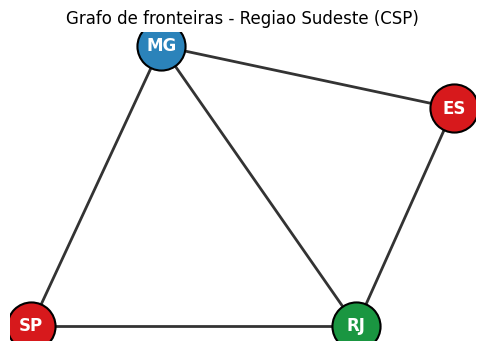

In [18]:
def solve_and_show_map_coloring():
    csp_map = create_map_coloring_csp()
    result = csp_map.backtracking_search(use_mrv=False)
    coloring = result["solution"]

    print("=== Coloracao de Mapas: Regiao Sudeste ===")
    print("Tempo total (s):", round(result["time"], 6))
    print("Nos expandidos:", result["nodes_expanded"])
    print("Backtracks:", result["backtracks"])
    print("\nColoracao encontrada:")
    for state in ["SP", "RJ", "MG", "ES"]:
        print(f"{state}: {coloring[state]}")

    try:
        import matplotlib.pyplot as plt

        positions = {
            "SP": (0.20, 0.20),
            "RJ": (0.70, 0.20),
            "MG": (0.40, 0.65),
            "ES": (0.85, 0.55),
        }
        edges = [("SP", "RJ"), ("SP", "MG"), ("RJ", "MG"), ("RJ", "ES"), ("MG", "ES")]
        palette = {"Vermelho": "#d7191c", "Verde": "#1a9641", "Azul": "#2b83ba"}

        plt.figure(figsize=(6, 4))

        for a, b in edges:
            xa, ya = positions[a]
            xb, yb = positions[b]
            plt.plot([xa, xb], [ya, yb], color="#333333", linewidth=2, zorder=1)

        for state, (x, y) in positions.items():
            color = palette.get(coloring[state], "gray")
            plt.scatter([x], [y], s=1200, c=[color], edgecolors="black", linewidths=1.5, zorder=2)
            plt.text(x, y, state, ha="center", va="center", fontsize=12, color="white", weight="bold", zorder=3)

        plt.title("Grafo de fronteiras - Regiao Sudeste (CSP)")
        plt.axis("off")
        plt.show()
    except Exception as exc:
        print("\nNao foi possivel plotar o grafo:", exc)
        print("Arestas:", [("SP", "RJ"), ("SP", "MG"), ("RJ", "MG"), ("RJ", "ES"), ("MG", "ES")])


solve_and_show_map_coloring()

In [4]:
sudoku_iniciante = [
    5, 3, 0, 0, 7, 0, 0, 0, 0,
    6, 0, 0, 1, 9, 5, 0, 0, 0,
    0, 9, 8, 0, 0, 0, 0, 6, 0,
    8, 0, 0, 0, 6, 0, 0, 0, 3,
    4, 0, 0, 8, 0, 3, 0, 0, 1,
    7, 0, 0, 0, 2, 0, 0, 0, 6,
    0, 6, 0, 0, 0, 0, 2, 8, 0,
    0, 0, 0, 4, 1, 9, 0, 0, 5,
    0, 0, 0, 0, 8, 0, 0, 7, 9,
]

sudoku_intermediario = [
    0, 0, 5, 3, 0, 0, 0, 0, 0,
    8, 0, 0, 0, 0, 0, 0, 2, 0,
    0, 7, 0, 0, 1, 0, 5, 0, 0,
    4, 0, 0, 0, 0, 5, 3, 0, 0,
    0, 1, 0, 0, 7, 0, 0, 0, 6,
    0, 0, 3, 2, 0, 0, 0, 8, 0,
    0, 6, 0, 5, 0, 0, 0, 0, 9,
    0, 0, 4, 0, 0, 0, 0, 3, 0,
    0, 0, 0, 0, 0, 9, 7, 0, 0,
]

sudoku_hard = [
    8, 0, 0, 0, 0, 0, 0, 0, 0,
    0, 0, 3, 6, 0, 0, 0, 0, 0,
    0, 7, 0, 0, 9, 0, 2, 0, 0,
    0, 5, 0, 0, 0, 7, 0, 0, 0,
    0, 0, 0, 0, 4, 5, 7, 0, 0,
    0, 0, 0, 1, 0, 0, 0, 3, 0,
    0, 0, 1, 0, 0, 0, 0, 6, 8,
    0, 0, 8, 5, 0, 0, 0, 1, 0,
    0, 9, 0, 0, 0, 0, 4, 0, 0,
]

expected_solutions = {
    "Iniciante": [
        5, 3, 4, 6, 7, 8, 9, 1, 2,
        6, 7, 2, 1, 9, 5, 3, 4, 8,
        1, 9, 8, 3, 4, 2, 5, 6, 7,
        8, 5, 9, 7, 6, 1, 4, 2, 3,
        4, 2, 6, 8, 5, 3, 7, 9, 1,
        7, 1, 3, 9, 2, 4, 8, 5, 6,
        9, 6, 1, 5, 3, 7, 2, 8, 4,
        2, 8, 7, 4, 1, 9, 6, 3, 5,
        3, 4, 5, 2, 8, 6, 1, 7, 9,
    ],
    "Intermediario": [
        1, 4, 5, 3, 2, 7, 6, 9, 8,
        8, 3, 9, 6, 5, 4, 1, 2, 7,
        6, 7, 2, 9, 1, 8, 5, 4, 3,
        4, 9, 6, 1, 8, 5, 3, 7, 2,
        2, 1, 8, 4, 7, 3, 9, 5, 6,
        7, 5, 3, 2, 9, 6, 4, 8, 1,
        3, 6, 7, 5, 4, 2, 8, 1, 9,
        9, 8, 4, 7, 6, 1, 2, 3, 5,
        5, 2, 1, 8, 3, 9, 7, 6, 4,
    ],
    "Avancado": [
        8, 1, 2, 7, 5, 3, 6, 4, 9,
        9, 4, 3, 6, 8, 2, 1, 7, 5,
        6, 7, 5, 4, 9, 1, 2, 8, 3,
        1, 5, 4, 2, 3, 7, 8, 9, 6,
        3, 6, 9, 8, 4, 5, 7, 2, 1,
        2, 8, 7, 1, 6, 9, 5, 3, 4,
        5, 2, 1, 9, 7, 4, 3, 6, 8,
        4, 3, 8, 5, 2, 6, 9, 1, 7,
        7, 9, 6, 3, 1, 8, 4, 5, 2,
    ],
}

sudoku_cases = {
    "Iniciante": sudoku_iniciante,
    "Intermediario": sudoku_intermediario,
    "Avancado": sudoku_hard,
}

In [19]:
def run_sudoku_experiment(case_name, puzzle, use_mrv, time_limit=50.0):
    csp = create_sudoku_csp(puzzle)
    result = csp.backtracking_search(use_mrv=use_mrv, time_limit=time_limit)
    solved_grid = assignment_to_grid(result["solution"])

    status = "Resolvido"
    if result["timed_out"]:
        status = "Timeout"
    elif solved_grid is None:
        status = "Sem solucao"

    expected = expected_solutions[case_name]
    is_correct = solved_grid == expected if solved_grid is not None else False

    return {
        "Caso": case_name,
        "Estrategia": "MRV" if use_mrv else "Busca cega",
        "Status": status,
        "Correto": is_correct,
        "Tempo (s)": result["time"],
        "Nos expandidos": result["nodes_expanded"],
        "Backtracks": result["backtracks"],
        "Solucao": solved_grid,
    }


def print_metrics_table(rows):
    header = f"{'Caso':<15} {'Estrategia':<12} {'Status':<10} {'Correto':<8} {'Tempo (s)':>10} {'Nos':>10} {'Backtracks':>12}"
    print(header)
    print("-" * len(header))
    for row in rows:
        print(
            f"{row['Caso']:<15} {row['Estrategia']:<12} {row['Status']:<10} {str(row['Correto']):<8} "
            f"{row['Tempo (s)']:>10.6f} {row['Nos expandidos']:>10} {row['Backtracks']:>12}"
        )


all_results = []


def run_case(case_name, time_blind=100.0, time_mrv=20.0):
    puzzle = sudoku_cases[case_name]
    blind = run_sudoku_experiment(case_name, puzzle, use_mrv=False, time_limit=time_blind)
    mrv = run_sudoku_experiment(case_name, puzzle, use_mrv=True, time_limit=time_mrv)

    all_results.extend([blind, mrv])

    print(f"=== Caso {case_name}: Busca Cega vs MRV ===")
    print_metrics_table([blind, mrv])

    print("\nSolucao com MRV:")
    print_sudoku(mrv["Solucao"])

## Busca Cega vs MRV no Sudoku

A diferenca de desempenho acontece por causa da **ordem de escolha das variaveis** durante o backtracking.

- **Busca cega**: escolhe a proxima celula vazia sem criterio (por ordem fixa).
- **MRV (Minimum Remaining Values)**: escolhe primeiro a celula com **menos valores validos restantes**.

Por que isso muda tanto?

- Em Sudoku, algumas celulas ficam muito restritas cedo (as vezes so 1 ou 2 opcoes).
- A busca cega pode gastar muito tempo tentando celulas "abertas" (com muitas opcoes), criando uma arvore enorme.
- O MRV ataca primeiro as partes mais restritas do problema, detecta inconsistencias cedo e reduz drasticamente o numero de ramificacoes.

Efeito pratico observado nas metricas:

- **Tempo total** cai bastante com MRV.
- **Nos expandidos** diminuem porque a arvore de busca fica menor.
- **Backtracks** diminuem porque escolhas ruins sao descartadas mais cedo.

Resumo: o MRV nao muda as regras do Sudoku, mas muda a estrategia de exploracao, tornando o CSP viavel para casos mais dificeis.

In [20]:
# Execucao 1: Sudoku Iniciante
run_case("Iniciante", time_blind=100.0, time_mrv=20.0)

=== Caso Iniciante: Busca Cega vs MRV ===
Caso            Estrategia   Status     Correto   Tempo (s)        Nos   Backtracks
-----------------------------------------------------------------------------------
Iniciante       Busca cega   Resolvido  True      82.690044   14740819     14740738
Iniciante       MRV          Resolvido  True       0.016427         81            0

Solucao com MRV:
5 3 4 | 6 7 8 | 9 1 2
6 7 2 | 1 9 5 | 3 4 8
1 9 8 | 3 4 2 | 5 6 7
---------------------
8 5 9 | 7 6 1 | 4 2 3
4 2 6 | 8 5 3 | 7 9 1
7 1 3 | 9 2 4 | 8 5 6
---------------------
9 6 1 | 5 3 7 | 2 8 4
2 8 7 | 4 1 9 | 6 3 5
3 4 5 | 2 8 6 | 1 7 9


In [ ]:
# Execucao 2: Sudoku Intermediario
run_case("Intermediario", time_blind=20.0, time_mrv=20.0)

In [ ]:
# Execucao 3: Sudoku Avancado
run_case("Avancado", time_blind=20.0, time_mrv=20.0)

In [ ]:
# Resumo final de todos os casos
print("=== Resumo Final: Todos os Casos ===")
print_metrics_table(all_results)